In [1]:
%%markdown
## Step 1: 에이전트 설계

- 이름: 에이전트의 이름은?
  - edu-planner-agent
- 목적: 어떤 문제를 해결하나요?
  - 학생들이 효과적으로 학습 계획을 세우고 목표를 달성하도록 돕습니다.
- 핵심 기능: 최소 3가지 주요 기능
  - 학습 목표 설정: 학생들이 달성하고자 하는 학습 목표를 정의하도록 돕습니다.
  - 맞춤형 학습 계획 생성: 학생의 목표, 시간 가용성
  - 선호하는 학습 스타일을 기반으로 개인화된 학습 계획을 만듭니다.
- 그래프 구조: 노드와 엣지 다이어그램 (손그림도 OK)

## Step 1: 에이전트 설계

- 이름: 에이전트의 이름은?
  - edu-planner-agent
- 목적: 어떤 문제를 해결하나요?
  - 학생들이 효과적으로 학습 계획을 세우고 목표를 달성하도록 돕습니다.
- 핵심 기능: 최소 3가지 주요 기능
  - 학습 목표 설정: 학생들이 달성하고자 하는 학습 목표를 정의하도록 돕습니다.
  - 맞춤형 학습 계획 생성: 학생의 목표, 시간 가용성
  - 선호하는 학습 스타일을 기반으로 개인화된 학습 계획을 만듭니다.
- 그래프 구조: 노드와 엣지 다이어그램 (손그림도 OK)


In [2]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict
from openai import OpenAI

client = OpenAI()

class State(TypedDict):
    subject: str
    level: str
    diagnosis: str
    study_plan: str
    quiz: str

def diagnose_level(state: State):
    """학생의 현재 수준을 진단"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": "You are an education expert. Diagnose the student's current level based on their subject and self-reported level. Respond in Korean, 2-3 sentences."
        }, {
            "role": "user",
            "content": f"과목: {state['subject']}, 자기 평가 수준: {state['level']}"
        }]
    )
    return {"diagnosis": response.choices[0].message.content}

def create_study_plan(state: State):
    """진단 결과를 바탕으로 맞춤 학습 계획 생성"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": "You are an education planner. Create a 1-week personalized study plan based on the diagnosis. Respond in Korean with bullet points."
        }, {
            "role": "user",
            "content": f"과목: {state['subject']}\n진단: {state['diagnosis']}"
        }]
    )
    return {"study_plan": response.choices[0].message.content}

def generate_quiz(state: State):
    """학습 계획에 맞는 진단 퀴즈 생성"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": "You are a quiz maker. Generate 3 multiple-choice questions matching the study plan difficulty. Respond in Korean."
        }, {
            "role": "user",
            "content": f"과목: {state['subject']}\n학습 계획: {state['study_plan']}"
        }]
    )
    return {"quiz": response.choices[0].message.content}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("diagnose_level", diagnose_level)
graph_builder.add_node("create_study_plan", create_study_plan)
graph_builder.add_node("generate_quiz", generate_quiz)

graph_builder.add_edge(START, "diagnose_level")
graph_builder.add_edge("diagnose_level", "create_study_plan")
graph_builder.add_edge("create_study_plan", "generate_quiz")
graph_builder.add_edge("generate_quiz", END)

graph = graph_builder.compile()

result = graph.invoke({
    "subject": "파이썬 프로그래밍",
    "level": "기초 문법은 알지만 클래스와 함수형 프로그래밍은 어려워요"
})

print("=== 수준 진단 ===")
print(result["diagnosis"])
print("\n=== 1주 학습 계획 ===")
print(result["study_plan"])
print("\n=== 진단 퀴즈 ===")
print(result["quiz"])

=== 수준 진단 ===
학생은 파이썬 프로그래밍의 기초 문법을 이해하고 있으나, 클래스와 함수형 프로그래밍에 어려움을 느끼고 있습니다. 현재 수준은 기본적인 프로그래밍 지식이 있는 초급 수준으로 보입니다. 다음 단계로 나아가기 위해서는 클래스와 함수형 프로그래밍의 개념을 체계적으로 학습할 필요가 있습니다.

=== 1주 학습 계획 ===
### 1주일 맞춤 학습 계획 (파이썬 프로그래밍)

#### 월요일: 클래스 기초 이해
- **오전:** 클래스의 기본 개념 및 정의 학습 (문서 및 동영상 자료 참고)
- **오후:** 클래스의 속성(attribute)과 메소드(method) 이해하기
- **저녁:** 간단한 클래스 예제 작성 (학생, 자동차 등)

#### 화요일: 클래스 심화
- **오전:** 생성자(__init__)와 소멸자(__del__) 이해하기
- **오후:** 클래스 상속(inheritance)과 오버라이딩(overriding) 개념 학습 
- **저녁:** 상속을 활용한 간단한 클래스 구조 구현

#### 수요일: 함수형 프로그래밍 기초
- **오전:** 함수형 프로그래밍 개념 및 lambda 함수 학습
- **오후:** map, filter, reduce 함수 사용법 이해하기
- **저녁:** 함수를 활용한 데이터 처리 예제 작성

#### 목요일: 클래스와 함수형 프로그래밍 혼합
- **오전:** 클래스 메소드를 활용한 함수형 프로그래밍 이해
- **오후:** 클래스 내에서 고차 함수 사용 예제 작성
- **저녁:** 자신의 클래스에 고차 함수 적용하여 재사용성 향상 실습

#### 금요일: 프로젝트 기획 및 설계
- **오전:** 자신이 좋아하는 주제를 정해 미니 프로젝트 기획
- **오후:** 프로젝트를 위한 클래스 구조 설계 및 오버뷰 작성
- **저녁:** 함수형 프로그래밍 기법 활용 아이디어 구상

#### 토요일: 프로젝트 구현
- **오전:** 기획한 내용을 바탕으로 코드 작성 시작
- **오후:** 구현 중 마주치는 문제점

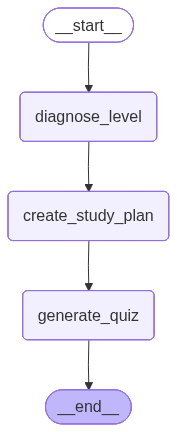

In [3]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))